<a href="https://colab.research.google.com/github/Iqra-kamil/Pythonclass/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

X_train (raw): (571, 8)
X_test (raw): (143, 8)
y_train: (571,)
y_test : (143,)


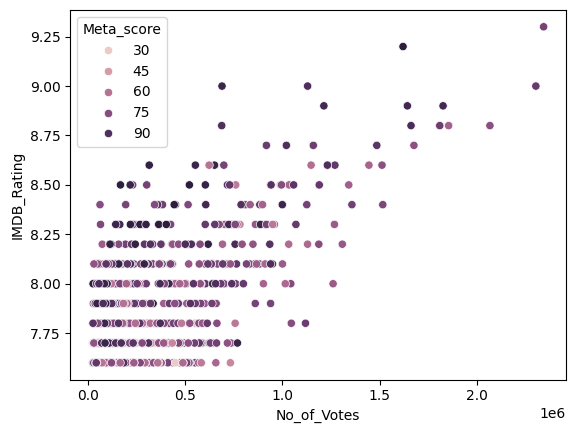

In [16]:
import pandas as pd
url = "https://raw.githubusercontent.com/Iqra-kamil/Pythonclass/refs/heads/main/imdb_top_1000.csv"

df = pd.read_csv(url)

import seaborn as sns

df = df.drop(columns=[
    "Poster_Link",
    "Series_Title",
    "Overview",
    "Star1",
    "Star2",
    "Star3",
    "Star4"
])

df["Runtime"] = df["Runtime"].str.replace(" min", "", regex=False)

df["Gross"] = df["Gross"].str.replace(",", "", regex=False)

df["Runtime"] = pd.to_numeric(df["Runtime"], errors='coerce')
df["Gross"] = pd.to_numeric(df["Gross"], errors='coerce')

df.dropna(subset=['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Runtime', 'Gross', 'Genre', 'Certificate'], inplace=True)

sns.scatterplot(
    data=df,
    x="No_of_Votes",
    y="IMDB_Rating",
    hue="Meta_score"
)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Features (X)
X = df.drop(columns=["IMDB_Rating"])

# Target (y)
y = df["IMDB_Rating"]


categorical_features = ['Certificate', 'Genre']
numerical_features = X.select_dtypes(include=['number']).columns.tolist()


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ],
    remainder='drop'
)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


print("X_train (raw):", X_train.shape)
print("X_test (raw):", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)



In [20]:
import joblib

model = LinearRegression()

X_train_transformed = preprocessor.fit_transform(X_train)

model.fit(X_train_transformed, y_train)

joblib.dump(model, "linear_regression_model.joblib")

print("Linear Regression model saved.")

Linear Regression model saved.
